In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Load datasets
fund = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
perf = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
txn = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [4]:
for name, df in {
    "Fund": fund,
    "NAV": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Performance": perf,
    "Transactions": txn,
    "Holdings": holdings,
    "Benchmark": benchmark
}.items():
    print(f"\n{name}")
    print(df.columns.tolist())


Fund
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

NAV
['amfi_code', 'date', 'nav']

AUM
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

Category
['month', 'category', 'net_inflow_crore']

Performance
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

Transactions
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annu

In [5]:
fund = pd.read_csv("../data/raw/01_fund_master.csv")

fund.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


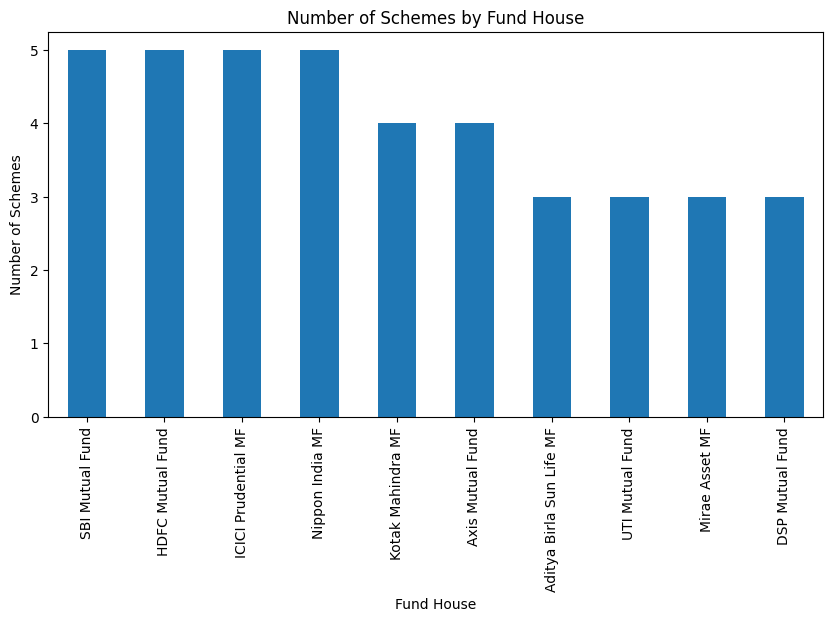

In [6]:
fund["fund_house"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Number of Schemes by Fund House")
plt.xlabel("Fund House")
plt.ylabel("Number of Schemes")
plt.show()

### Observation

- SBI Mutual Fund, HDFC Mutual Fund, ICICI Prudential MF, and Nippon India MF have the highest number of schemes in the dataset, with 5 schemes each.
- Kotak Mahindra MF and Axis Mutual Fund follow with 4 schemes each.
- Aditya Birla Sun Life MF, UTI Mutual Fund, Mirae Asset MF, and DSP Mutual Fund have relatively fewer schemes.
- The distribution suggests that scheme offerings are concentrated among a few major fund houses.

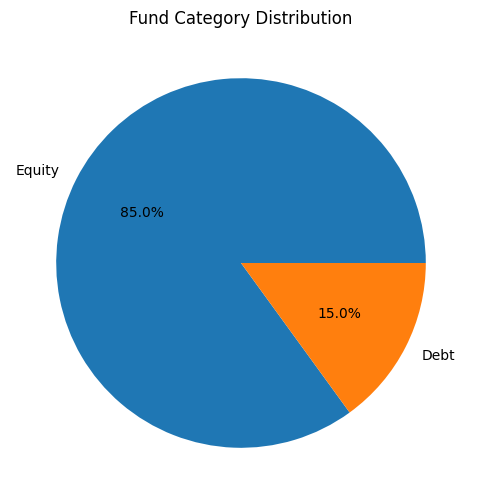

In [7]:
fund["category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Fund Category Distribution")
plt.ylabel("")
plt.show()

### Observation

- Equity funds dominate the dataset, accounting for 85% of all schemes.
- Debt funds represent only 15% of the schemes.
- This indicates a strong focus on equity-oriented investment products in the mutual fund universe.
- The higher representation of equity funds reflects investor preference for long-term capital appreciation.

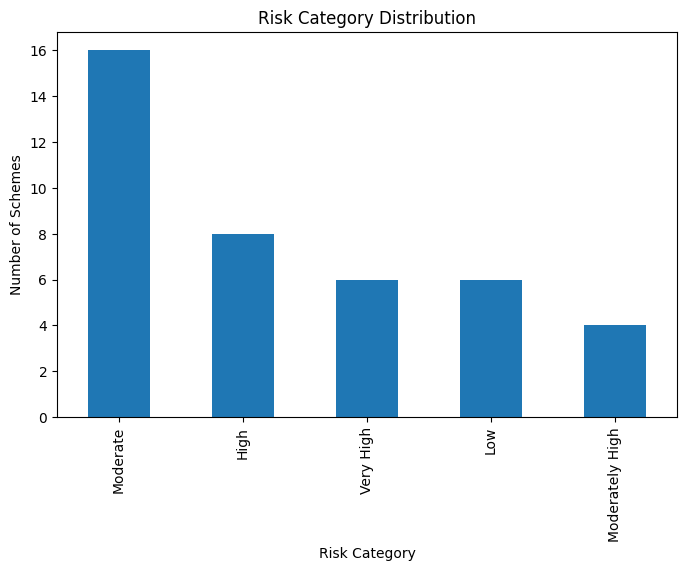

In [8]:
fund["risk_category"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Schemes")
plt.show()

### Observation

- Moderate risk schemes form the largest segment in the dataset, with 16 schemes.
- High risk schemes account for 8 schemes.
- Very High and Low risk categories each contain 6 schemes.
- Moderately High risk schemes are the least represented category.
- The distribution suggests that fund offerings are concentrated around moderate-risk investment products, balancing growth potential and risk.

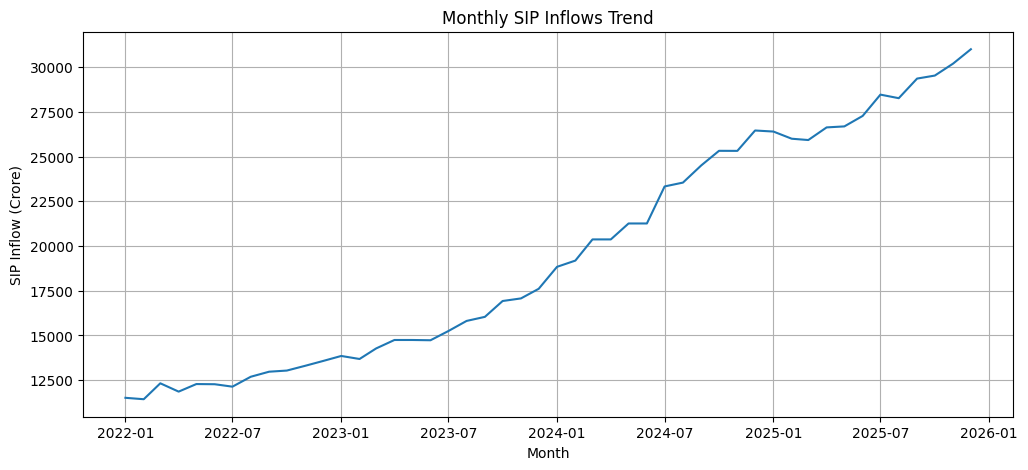

In [9]:
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(12,5))
plt.plot(sip["month"], sip["sip_inflow_crore"])

plt.title("Monthly SIP Inflows Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.grid(True)

plt.show()

### Observation

- Monthly SIP inflows show a strong upward trend from 2022 to 2025.
- SIP inflows increased from approximately ₹11,000 crore in early 2022 to over ₹31,000 crore by the end of 2025.
- Growth accelerated significantly during 2024 and 2025, indicating rising retail investor participation in mutual funds.
- The consistent increase suggests growing investor confidence and greater adoption of SIP-based investing.

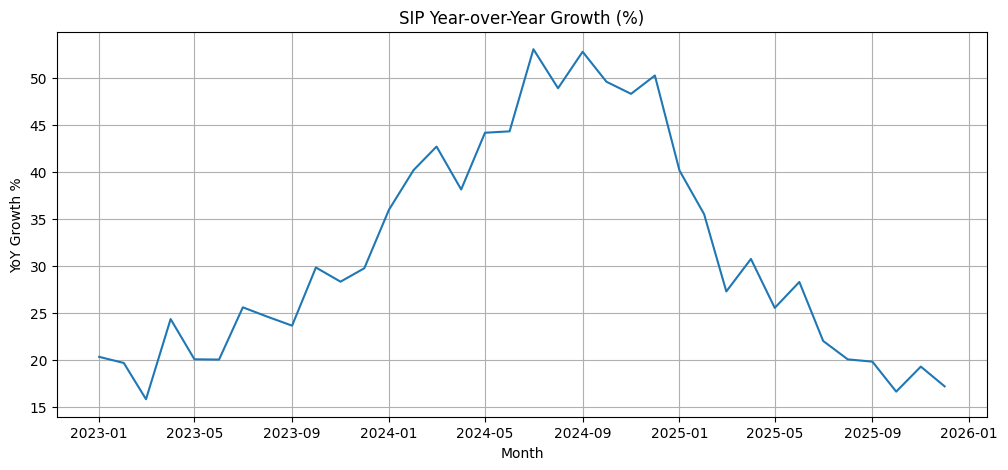

In [10]:
plt.figure(figsize=(12,5))

plt.plot(
    sip["month"],
    sip["yoy_growth_pct"]
)

plt.title("SIP Year-over-Year Growth (%)")
plt.xlabel("Month")
plt.ylabel("YoY Growth %")
plt.grid(True)

plt.show()

### Observation

- SIP YoY growth remained positive for most of the period.
- Growth rates fluctuated over time, reflecting changing market conditions and investor sentiment.
- Despite short-term variations, the overall trend indicates sustained expansion in SIP participation.
- Increasing SIP contributions highlight growing awareness of systematic investing among retail investors.

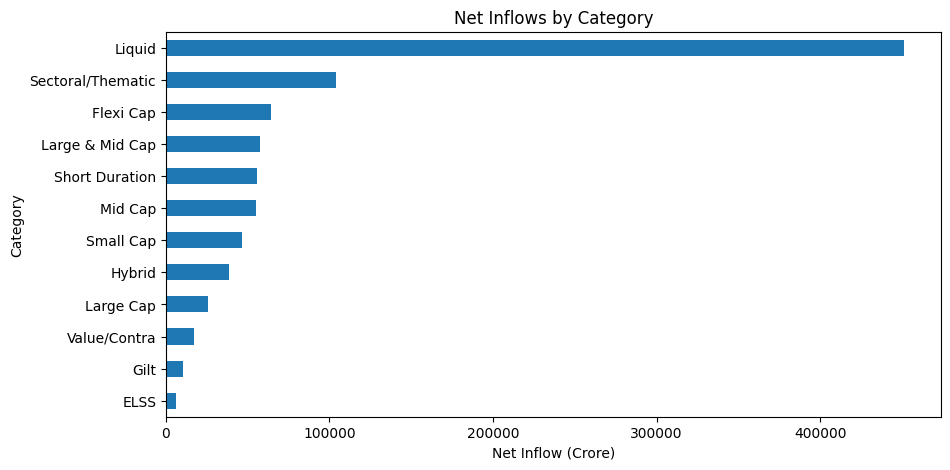

In [11]:
category.groupby("category")["net_inflow_crore"] \
        .sum() \
        .sort_values() \
        .plot(kind="barh", figsize=(10,5))

plt.title("Net Inflows by Category")
plt.xlabel("Net Inflow (Crore)")
plt.ylabel("Category")
plt.show()

### Observation

- Net inflows vary significantly across fund categories.
- Certain categories attract substantially higher investor inflows, indicating stronger market preference.
- Categories with negative or relatively low inflows may reflect changing investor sentiment or profit-booking activity.
- Category-level flow analysis helps identify sectors and investment styles currently favored by investors.

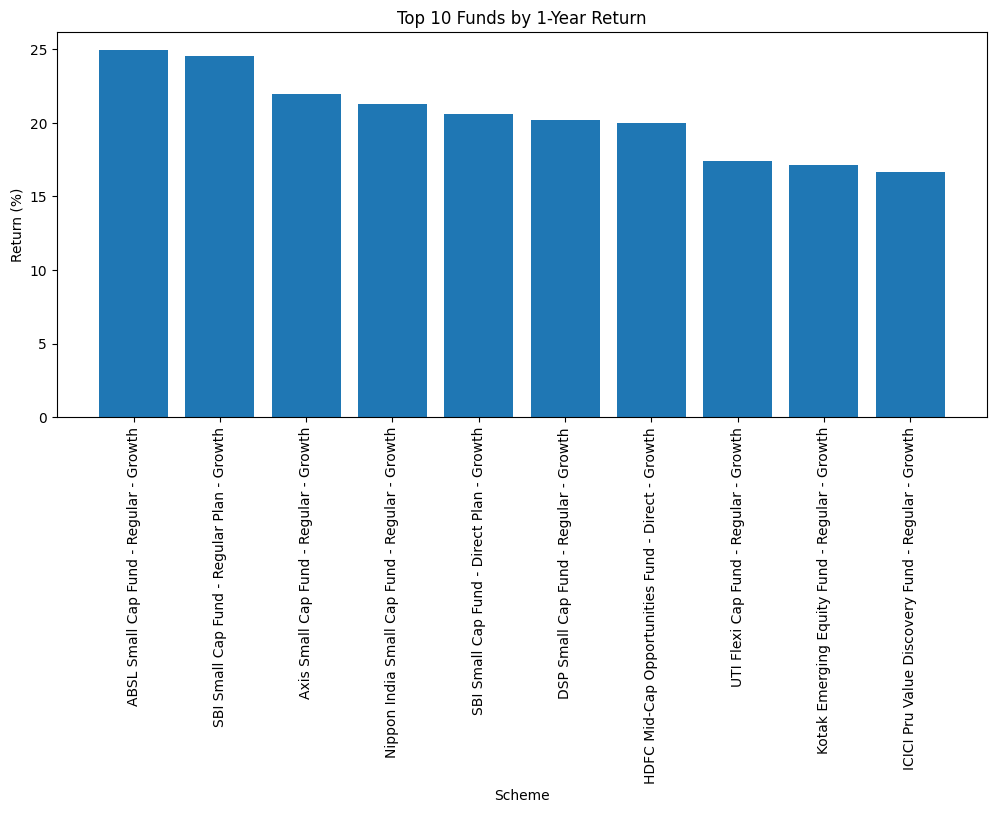

In [12]:
top10 = perf.sort_values(
    "return_1yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,5))
plt.bar(top10["scheme_name"], top10["return_1yr_pct"])

plt.title("Top 10 Funds by 1-Year Return")
plt.xlabel("Scheme")
plt.ylabel("Return (%)")
plt.xticks(rotation=90)

plt.show()

### Observation

- The top 10 funds by 1-year return are dominated by Small Cap schemes, with ABSl Small Cap Fund and SBI Small Cap Fund leading at approximately 24–25%, indicating that small-cap funds delivered the strongest short-term performance in this period.
- Returns among the top 10 funds range from ~17% to ~25%, reflecting a relatively narrow performance band, which suggests broad market participation rather than returns driven by a single outlier fund.
- Small Cap funds from multiple fund houses — ABSL, SBI, Axis, Nippon India, SBI Direct, and DSP — all appear in the top 10, highlighting that the small-cap category as a whole outperformed other categories over the 1-year horizon.
- Mid-Cap and Flexi-Cap funds such as HDFC Mid-Cap Opportunities and UTI Flexi Cap appear in the lower half of the top 10, suggesting they delivered competitive but comparatively modest returns relative to pure small-cap strategies.
- The presence of both Regular and Direct plan variants of similar schemes confirms that fund selection and category allocation were more decisive performance drivers than plan type alone during this period.

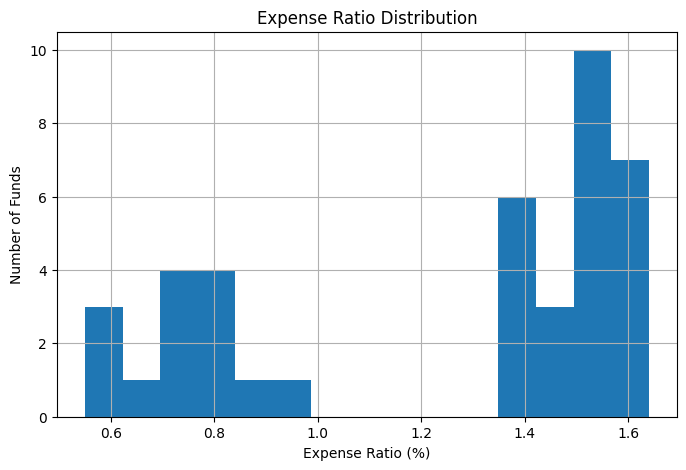

In [13]:
plt.figure(figsize=(8,5))
perf["expense_ratio_pct"].hist(bins=15)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Number of Funds")

plt.show()

### Observation

- The expense ratio distribution is distinctly bimodal, with one cluster concentrated in the 0.6–1.0% range and a larger cluster in the 1.4–1.7% range, suggesting two clearly separate tiers of funds — likely Direct plans and Regular plans respectively.
- The higher-cost cluster (1.4–1.7%) contains the majority of funds, with the 1.5–1.6% bin peaking at 10 funds, indicating that Regular plan schemes dominate the dataset in terms of count.
- The lower-cost cluster (0.6–0.9%) represents a smaller number of funds, most likely Direct plan variants, which typically carry lower expense ratios due to the absence of distributor commissions.
- The near-empty gap between 1.0% and 1.3% is notable — very few funds fall in this mid-range, reinforcing the structural separation between Direct and Regular plan pricing imposed by SEBI's total expense ratio regulations.
- From an investor perspective, the ~0.8–0.9% difference in expense ratios between the two clusters can compound significantly over long investment horizons, making plan-type selection a meaningful factor in net return outcomes.

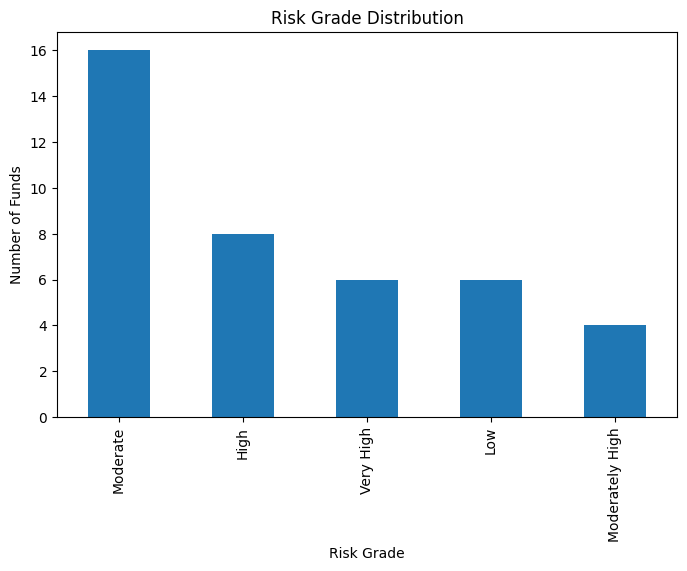

In [14]:
plt.figure(figsize=(8,5))
perf["risk_grade"].value_counts().plot(kind="bar")

plt.title("Risk Grade Distribution")
plt.xlabel("Risk Grade")
plt.ylabel("Number of Funds")

plt.show()